# 🔥 Heatmap Calendar (Year–Month–Day)

Using:

✔ Matplotlib

✔ Seaborn

✔ Pandas pivoting

✔ Custom color schemes

✔ Multiple years

✔ Monthly heatmap

✔ Yearly heatmap

✔ Week-based heatmap

✔ Full calendar-style heatmap

✔ Advanced grid layouts

✔ Day/Month labels, weekends shading

## Variation 1 — Full Calendar Heatmap (365-day view)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import calendar

# -----------------------------
# Generate sample data
# -----------------------------
dates = pd.date_range("2024-01-01", "2024-12-31")
values = np.random.randint(0, 100, len(dates))

df = pd.DataFrame({"date": dates, "value": values})
df['dow'] = df['date'].dt.weekday        # 0=Mon
df['week'] = df['date'].dt.isocalendar().week
df['week'] = df['week'].replace({53: 0})

# Create matrix: rows = weekdays, cols = weeks
heatmap_data = df.pivot(index='dow', columns='week', values='value')

plt.figure(figsize=(16, 4))
plt.imshow(heatmap_data, cmap="viridis", aspect='auto')

plt.yticks(range(7), ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"])
plt.title("Full-Year Calendar Heatmap (GitHub-Style)")
plt.colorbar(label="Value")
plt.show()


## Variation 2 — Month-by-Month Calendar (Real Calendar Layout)

Each month gets a real calendar grid (matrix of 5×7).

C:\Users\NIL\AppData\Local\Temp\ipykernel_15312\3726519084.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp['week_in_month'] = temp['date'].dt.day.apply(lambda d: (d-1)//7)
C:\Users\NIL\AppData\Local\Temp\ipykernel_15312\3726519084.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp['week_in_month'] = temp['date'].dt.day.apply(lambda d: (d-1)//7)
C:\Users\NIL\AppData\Local\Temp\ipykernel_15312\3726519084.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a D

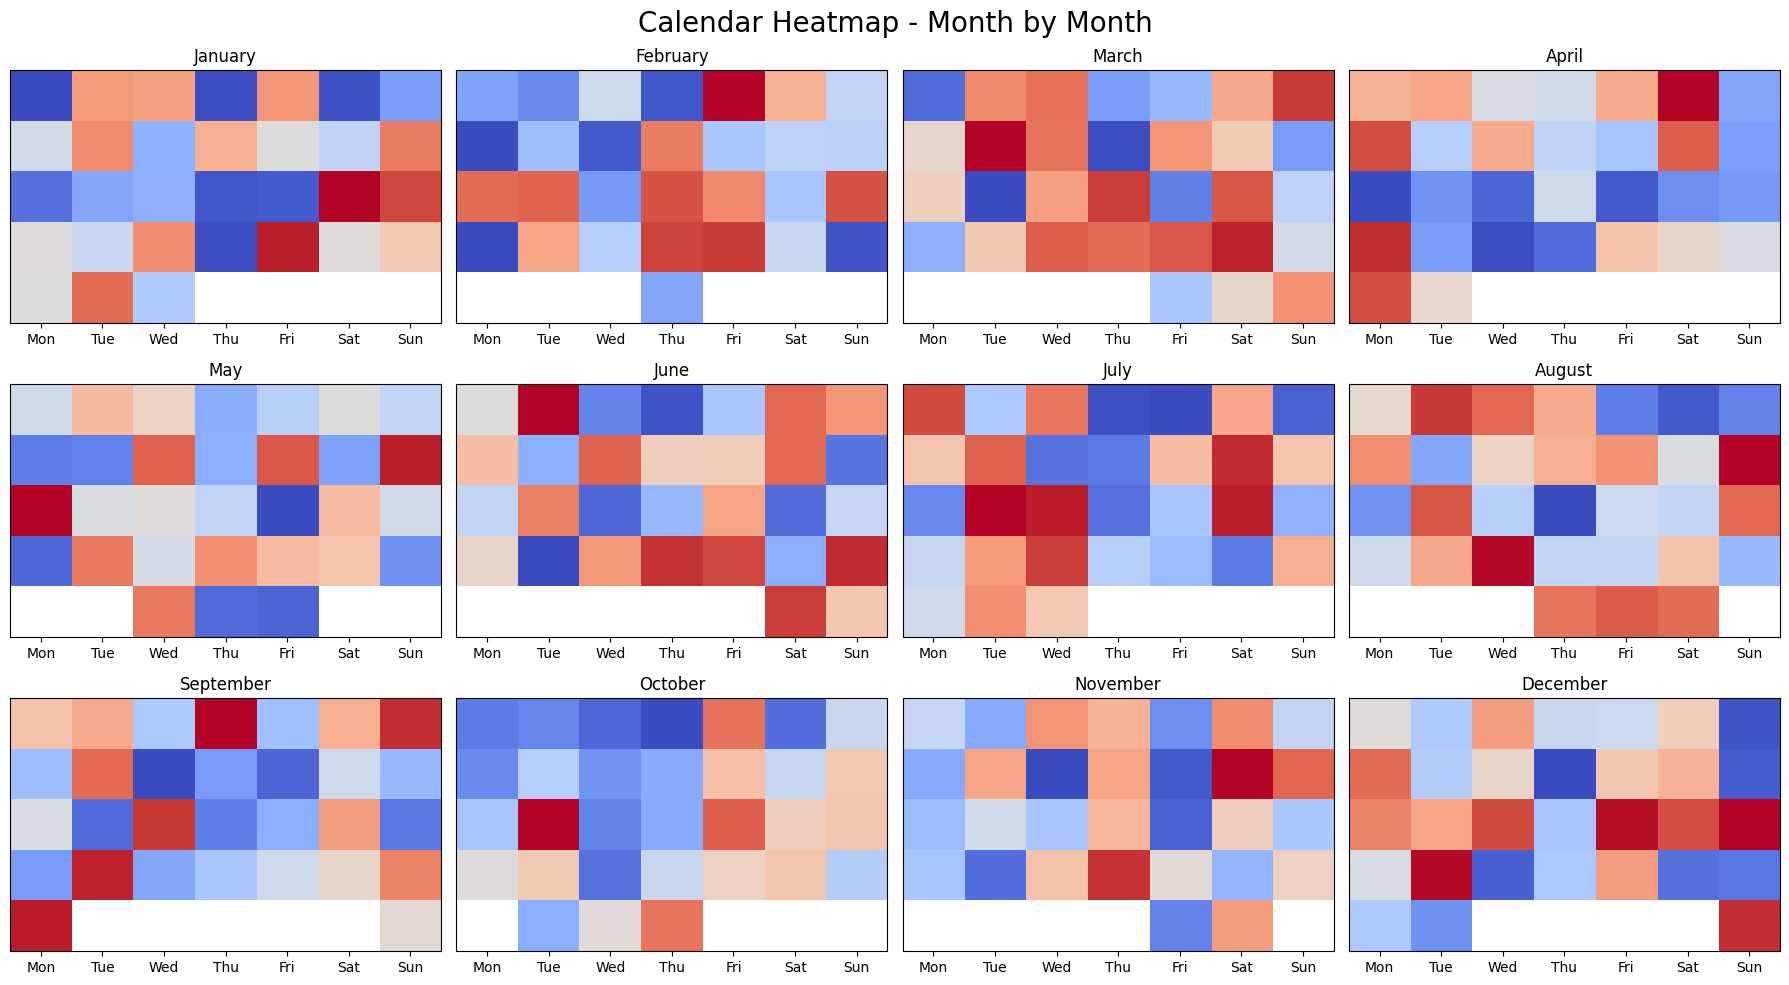

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import calendar

# ------------------------------------
# Generate sample data
# ------------------------------------
dates = pd.date_range("2024-01-01", "2024-12-31")
values = np.random.randint(0, 200, len(dates))
df = pd.DataFrame({"date": dates, "value": values})

df['dow'] = df['date'].dt.weekday
df['week'] = df['date'].dt.day // 7

fig, axes = plt.subplots(3, 4, figsize=(18, 10))
fig.suptitle("Calendar Heatmap - Month by Month", fontsize=20)

months = calendar.month_name[1:]

for i, month in enumerate(months):
    ax = axes[i // 4][i % 4]
    month_num = i + 1

    temp = df[df['date'].dt.month == month_num]
    temp['week_in_month'] = temp['date'].dt.day.apply(lambda d: (d-1)//7)

    matrix = temp.pivot(index='week_in_month', columns='dow', values='value')

    ax.imshow(matrix, cmap='coolwarm', aspect='auto')
    ax.set_title(month)
    ax.set_xticks(range(7))
    ax.set_xticklabels(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"])
    ax.set_yticks([])

plt.tight_layout()
plt.show()


## Monthly Heatmap (Month × Day)

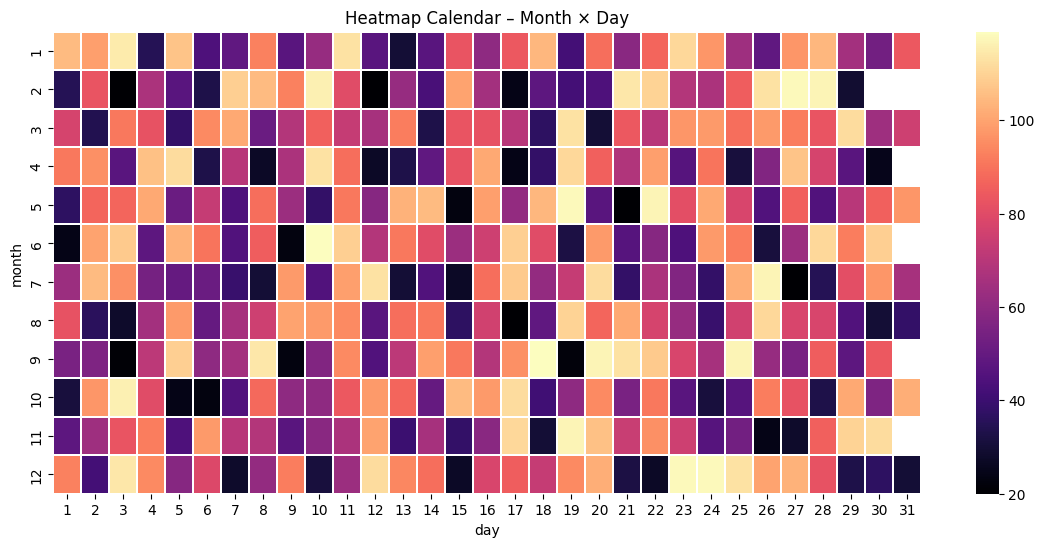

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

dates = pd.date_range("2024-01-01", "2024-12-31")
values = np.random.randint(20, 120, len(dates))

df = pd.DataFrame({"date": dates, "value": values})
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day

pivot = df.pivot(index="month", columns="day", values="value")

plt.figure(figsize=(14, 6))
sns.heatmap(pivot, cmap="magma", linewidths=0.2)
plt.title("Heatmap Calendar – Month × Day")
plt.show()


## Variation 4 — Daily Heatmap (Year-DayNumber)

1 row = 1 year
1 col = day of year (1–365)

In [12]:
df = pd.DataFrame({"date": dates, "value": values})
df['day_of_year'] = df['date'].dt.dayofyear
df['year'] = df['date'].dt.year

pivot = df.pivot("year", "day_of_year", "value")

plt.figure(figsize=(18, 3))
sns.heatmap(pivot, cmap="inferno")
plt.title("Day-of-Year Heatmap")
plt.show()


TypeError: DataFrame.pivot() takes 1 positional argument but 4 were given

## Variation 5 — Single-Month Heatmap (Week × Weekday)

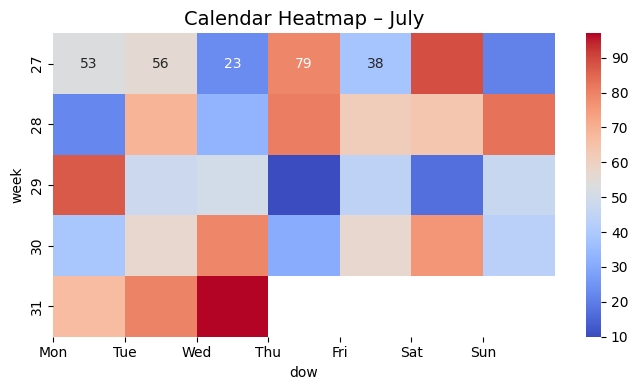

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import calendar

# ----------------------------------------
# Generate sample data for full year
# ----------------------------------------
dates = pd.date_range("2024-01-01", "2024-12-31")
values = np.random.randint(10, 100, len(dates))

df = pd.DataFrame({"date": dates, "value": values})

# ----------------------------------------
# Choose month
# ----------------------------------------
month = 7   # July

temp = df[df['date'].dt.month == month].copy()

# Week number & day of week
temp["week"] = temp['date'].dt.isocalendar().week.astype(int)
temp["dow"] = temp['date'].dt.weekday  # 0=Mon ... 6=Sun

# FIXED pivot call
pivot = temp.pivot(index="week", columns="dow", values="value")

plt.figure(figsize=(7, 4))
sns.heatmap(pivot, cmap="coolwarm", annot=True, fmt=".0f")

plt.title(f"Calendar Heatmap – {calendar.month_name[month]}", fontsize=14)
plt.xticks(range(7), ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
plt.tight_layout()
plt.show()


## Variation 6 — Year → Month Grids (12 heatmaps in one)

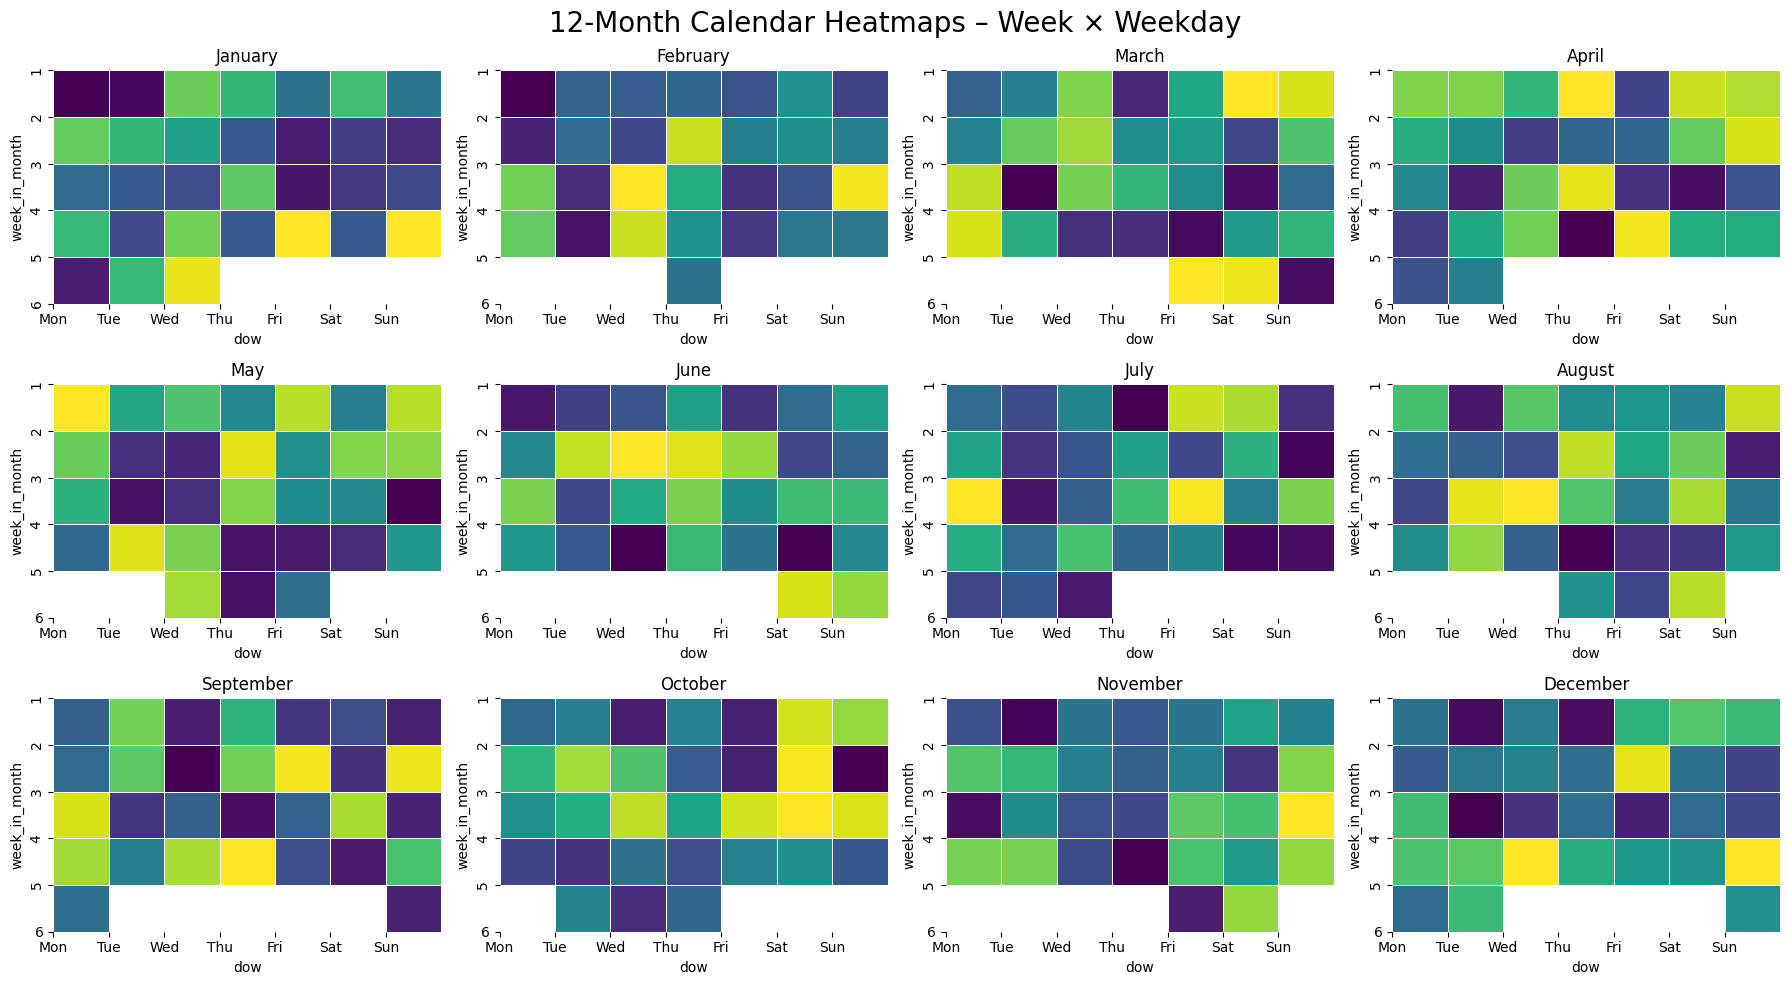

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import calendar

# -------------------------------------------------
# Generate sample daily data for one year
# -------------------------------------------------
dates = pd.date_range("2024-01-01", "2024-12-31")
values = np.random.randint(10, 100, len(dates))
df = pd.DataFrame({"date": dates, "value": values})

# Extract week & day of week
df["dow"] = df["date"].dt.weekday                  # 0=Mon
df["week_in_month"] = df["date"].dt.day.map(lambda d: (d-1)//7)

# -------------------------------------------------
# 12 Monthly Heatmaps (Proper Calendar Layout)
# -------------------------------------------------
fig, axes = plt.subplots(3, 4, figsize=(18, 10))
fig.suptitle("12-Month Calendar Heatmaps – Week × Weekday", fontsize=20)

for i in range(12):
    month = i + 1
    temp = df[df["date"].dt.month == month].copy()

    # Create calendar matrix (week rows × weekday columns)
    pivot = temp.pivot(index="week_in_month", columns="dow", values="value")

    ax = axes[i // 4][i % 4]
    sns.heatmap(pivot, cmap="viridis", ax=ax, cbar=False,
                linewidths=.5, linecolor="white")

    ax.set_title(calendar.month_name[month], fontsize=12)
    ax.set_xticks(range(7))
    ax.set_xticklabels(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
    ax.set_yticks(range(6))
    ax.set_yticklabels([1, 2, 3, 4, 5, 6])  # week numbers

plt.tight_layout()
plt.show()


## Variation 7 — Calendar Heatmap with Weekends Highlighted

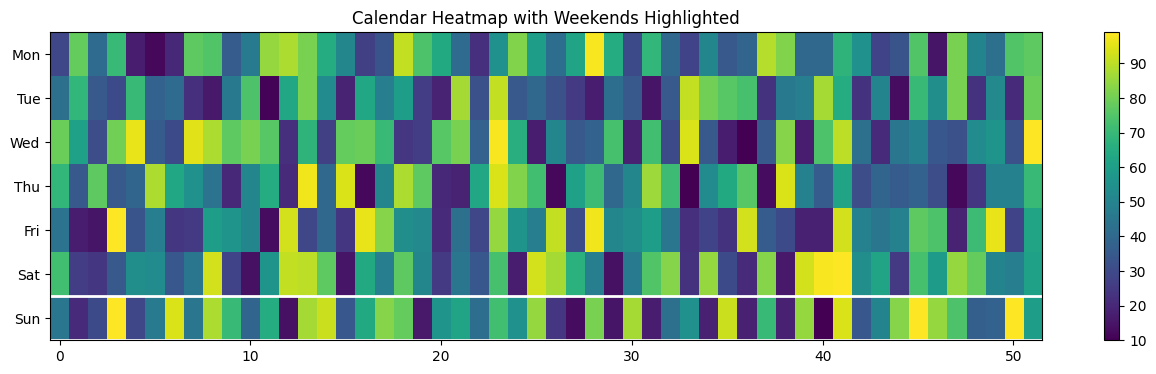

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Weekday & week
df['dow'] = df['date'].dt.weekday
df['week'] = df['date'].dt.isocalendar().week.astype(int)
df['week'] = df['week'].replace({53: 0})

# FIX: Use pivot_table instead of pivot
matrix = df.pivot_table(
    index='dow',
    columns='week',
    values='value',
    aggfunc='mean'
)

plt.figure(figsize=(16,4))
img = plt.imshow(matrix, cmap="viridis", aspect="auto")

# Shade weekends
for i in [5, 6]:
    plt.axhline(i + .5, color='white', linewidth=2)

plt.yticks(range(7), ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"])
plt.colorbar(img)
plt.title("Calendar Heatmap with Weekends Highlighted")
plt.show()


## Variation 8 — Calendar Heatmap with Missing Days Filled


In [7]:
df = df.set_index("date").asfreq("D").fillna(method="ffill").reset_index()


C:\Users\NIL\AppData\Local\Temp\ipykernel_15312\2194811219.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.set_index("date").asfreq("D").fillna(method="ffill").reset_index()


## Variation 9 — Custom Colormaps

<Axes: xlabel='dow', ylabel='week_in_month'>

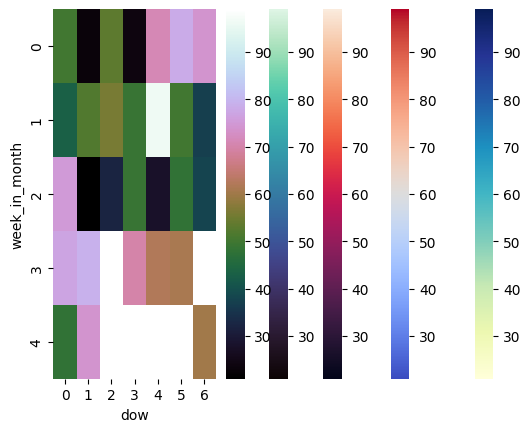

In [22]:
sns.heatmap(pivot, cmap="YlGnBu")
sns.heatmap(pivot, cmap="coolwarm")
sns.heatmap(pivot, cmap="rocket")
sns.heatmap(pivot, cmap="mako")
sns.heatmap(pivot, cmap="cubehelix")